**Dataset**

In [ ]:
import yfinance as yf # Import the yfinance library for downloading financial data

df = yf.download("AAPL", # Download historical stock data for Apple (AAPL)
                 start="2020-01-01", # Specify the start date for data download
                 end="2025-01-01") # Specify the end date for data download

/tmp/ipykernel_692/2587226153.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", # Download historical stock data for Apple (AAPL)
[*********************100%***********************]  1 of 1 completed


In [ ]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400
2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200
2020-01-07,71.861824,72.466307,71.642666,72.211026,108872000
2020-01-08,73.017822,73.318862,71.565606,71.565606,132079200
...,...,...,...,...,...
2024-12-24,256.560822,256.570737,253.669277,253.868019,23234700
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100


**Install Libraries**

In [ ]:
pip install yfinance tensorflow scikit-learn matplotlib

**Import Libraries**

In [ ]:
import yfinance as yf # Import yfinance for financial data
import numpy as np # Import numpy for numerical operations
import matplotlib.pyplot as plt # Import matplotlib for plotting graphs

from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler for data normalization

from tensorflow.keras.models import Sequential # Import Sequential model from Keras
from tensorflow.keras.layers import SimpleRNN # Import SimpleRNN layer for recurrent neural networks
from tensorflow.keras.layers import Dense # Import Dense layer for fully connected neural networks

**Download Dataset**

In [ ]:
df = yf.download("AAPL", # Download historical stock data for Apple (AAPL)
                 start="2020-01-01", # Specify the start date for data download
                 end="2025-01-01") # Specify the end date for data download

data = df[['Close']] # Extract only the 'Close' price column from the DataFrame

/tmp/ipykernel_692/2756300748.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", # Download historical stock data for Apple (AAPL)
[*********************100%***********************]  1 of 1 completed


**Normalize**

In [ ]:
scaler = MinMaxScaler() # Initialize the MinMaxScaler to scale data between 0 and 1

scaled_data = scaler.fit_transform(data) # Fit the scaler to the 'Close' price data and transform it

**Create Sequences**

In [ ]:
X = [] # Initialize an empty list for input sequences (features)
y = [] # Initialize an empty list for target values (labels)

for i in range(60, len(scaled_data)): # Iterate through the scaled data to create sequences
    X.append(scaled_data[i-60:i]) # Append a sequence of the last 60 data points to X
    y.append(scaled_data[i]) # Append the current data point as the target to y

X = np.array(X) # Convert the list of input sequences X to a NumPy array
y = np.array(y) # Convert the list of target values y to a NumPy array

**Build RNN**

In [ ]:
model = Sequential() # Initialize a sequential Keras model

model.add( # Add a layer to the model
    SimpleRNN( # Add a SimpleRNN layer
        50, # The number of recurrent units (neurons) in the RNN layer
        input_shape=(60,1), # Define the input shape: 60 time steps, 1 feature per step
        activation='tanh' # Use the hyperbolic tangent activation function
    )
)

model.add(Dense(1)) # Add a Dense (fully connected) output layer with 1 neuron for regression

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Compile**

In [ ]:
model.compile( # Configure the model for training

    optimizer="adam", # Use the Adam optimizer for efficient gradient descent

    loss="mean_squared_error" # Use Mean Squared Error as the loss function for regression

)

**Train**

In [ ]:
history = model.fit( # Train the model

    X, # Input features (sequences)

    y, # Target labels

    epochs=20, # Train for 20 epochs (passes over the entire dataset)

    batch_size=32 # Process data in batches of 32 samples

)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0490
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0021
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0014
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0010    
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.3780e-04
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.8948e-04
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 7.7360e-04
Epoch 9/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 7.2048e-04
Epoch 10/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 6.9831e-04
Epoch 11/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6.3720e-04
Epoch 12/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.9126e-04
Epoch 13/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.9561e-04
Epoch 14/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.8774e-04
Epoch 15/20
38/38 ━━━━━━━━━━━━━

**Prediction**

In [ ]:
predictions = model.predict(X) # Generate predictions using the trained model on the input data X

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


**Plot**

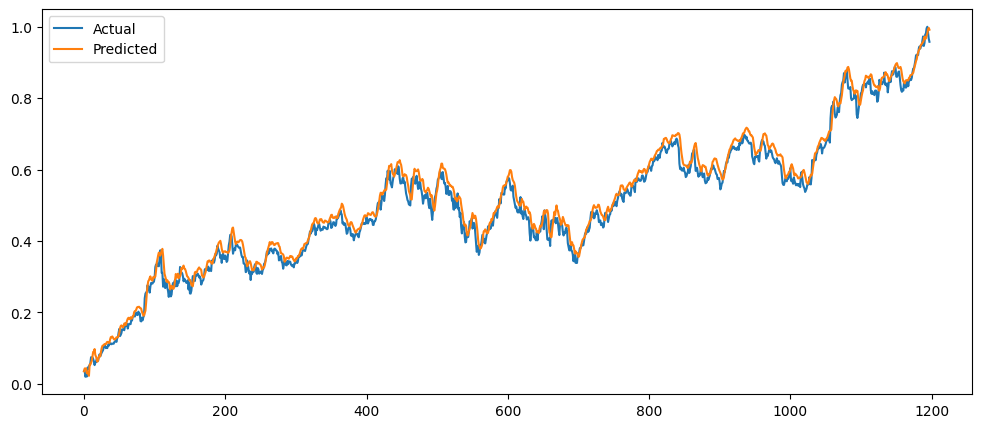

In [ ]:
plt.figure(figsize=(12,5)) # Create a new figure with a specified size for plotting

plt.plot(y, label="Actual") # Plot the actual closing prices with a label

plt.plot(predictions, label="Predicted") # Plot the predicted closing prices with a label

plt.legend() # Display the legend to differentiate actual and predicted plots

plt.show() # Show the generated plot